# Introduction


Each penguin is from one of the three following species: Adelie, Gentoo, and Chinstrap. See the illustration below depicting the three different penguin species:


![img1](https://github.com/allisonhorst/palmerpenguins/raw/main/man/figures/lter_penguins.png)

### What penguin is this?

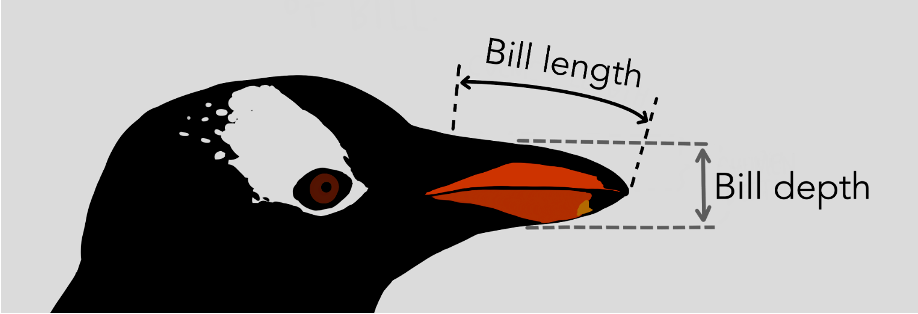




> We start by loading this subset of the dataset.




In [ ]:
import pandas as pd
penguins = pd.read_csv("../../data/datasets/penguins.csv")

# Note in the raw data, bill dimensions are recorded as "culmen length" and "culmen depth".

# penguins

culmen_columns = ["Culmen Length (mm)", "Culmen Depth (mm)"]
target_column = "Species"

penguins_classification = penguins[culmen_columns + [target_column]]



> Let’s check the dataset more into details.



In [ ]:
penguins_classification

,Culmen Length (mm),Culmen Depth (mm),Species
0,39.1,18.7,Adelie Penguin (Pygoscelis adeliae)
1,39.5,17.4,Adelie Penguin (Pygoscelis adeliae)
2,40.3,18.0,Adelie Penguin (Pygoscelis adeliae)
3,NaN,NaN,Adelie Penguin (Pygoscelis adeliae)
4,36.7,19.3,Adelie Penguin (Pygoscelis adeliae)
...,...,...,...
339,55.8,19.8,Chinstrap penguin (Pygoscelis antarctica)
340,43.5,18.1,Chinstrap penguin (Pygoscelis antarctica)
341,49.6,18.2,Chinstrap penguin (Pygoscelis antarctica)
342,50.8,19.0,Chinstrap penguin (Pygoscelis antarctica)




> We can check a scatter plot to observe the samples distribution.



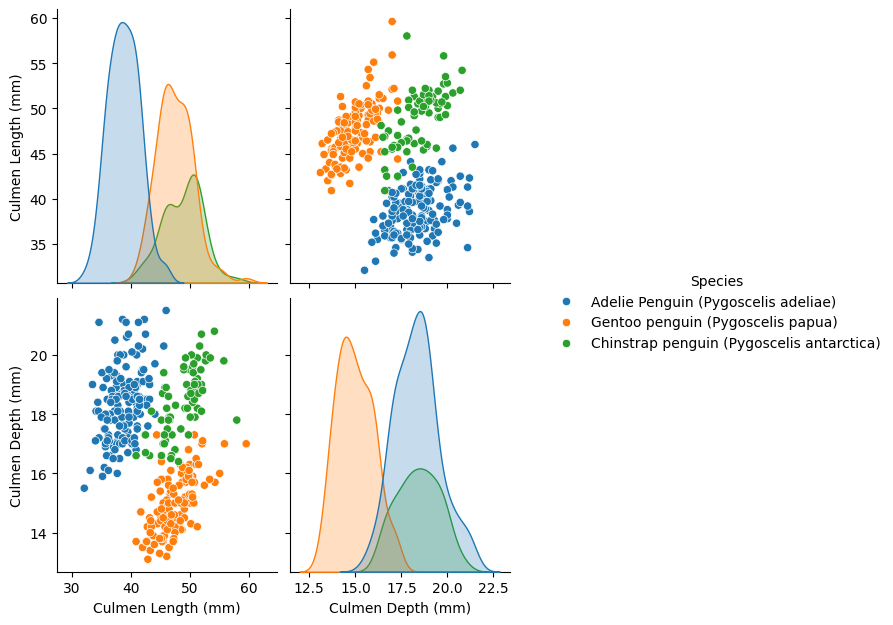

In [ ]:
import seaborn as sns

pairplot_figure = sns.pairplot(penguins_classification, hue="Species")
pairplot_figure.fig.set_size_inches(9, 6.5)

First let’s check the feature distributions by looking at the diagonal plots of the pairplot. We can deduce the following intuitions:

*   The Adelie species can be differentiated from the Gentoo and Chinstrap species depending on the culmen length;
*   The Gentoo species can be differentiated from the Adelie and Chinstrap species depending on the culmen depth.

# Data Exploration

Imagine we are interested in predicting penguins species based on two of their body measurements: culmen length and culmen depth. First we want to do some data exploration to get a feel for the data.

What are the features? What is the target?

Load the data with pandas into a DataFrame.

In [ ]:
import pandas as pd
penguins = pd.read_csv("./penguins.csv")

# Note in the raw data, bill dimensions are recorded as "culmen length" and "culmen depth".

# penguins

culmen_columns = ["Culmen Length (mm)", "Culmen Depth (mm)"]
target_column = "Species"

penguins_classification = penguins[culmen_columns + [target_column]]

Show a few samples of the data.

How many features are numerical? How many features are categorical?

In [ ]:
penguins_classification.head()

,Culmen Length (mm),Culmen Depth (mm),Species
0,39.1,18.7,Adelie Penguin (Pygoscelis adeliae)
1,39.5,17.4,Adelie Penguin (Pygoscelis adeliae)
2,40.3,18.0,Adelie Penguin (Pygoscelis adeliae)
3,NaN,NaN,Adelie Penguin (Pygoscelis adeliae)
4,36.7,19.3,Adelie Penguin (Pygoscelis adeliae)


What are the different penguins species available in the dataset and how many samples of each species are there?

See: [value_counts](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.value_counts.html)


In [ ]:
penguins_classification[target_column].value_counts()

,count
Species,
Adelie Penguin (Pygoscelis adeliae),152
Gentoo penguin (Pygoscelis papua),124
Chinstrap penguin (Pygoscelis antarctica),68


Plot histograms for the numerical features


array([[<Axes: title={'center': 'Culmen Length (mm)'}>,
        <Axes: title={'center': 'Culmen Depth (mm)'}>]], dtype=object)

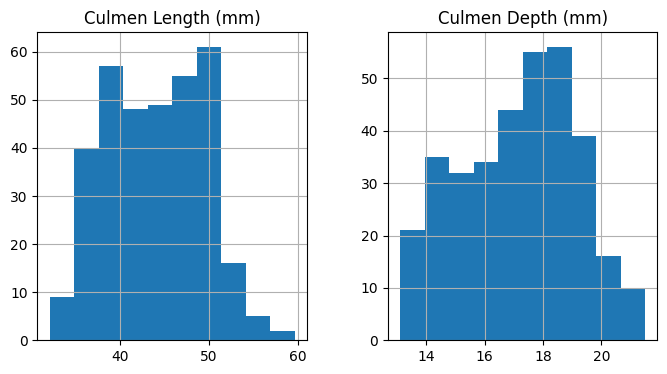

In [ ]:
penguins_classification.hist(figsize=(8, 4))

Show features distribution for each class. See: [seaborn.pairplot](https://seaborn.pydata.org/generated/seaborn.pairplot.html)

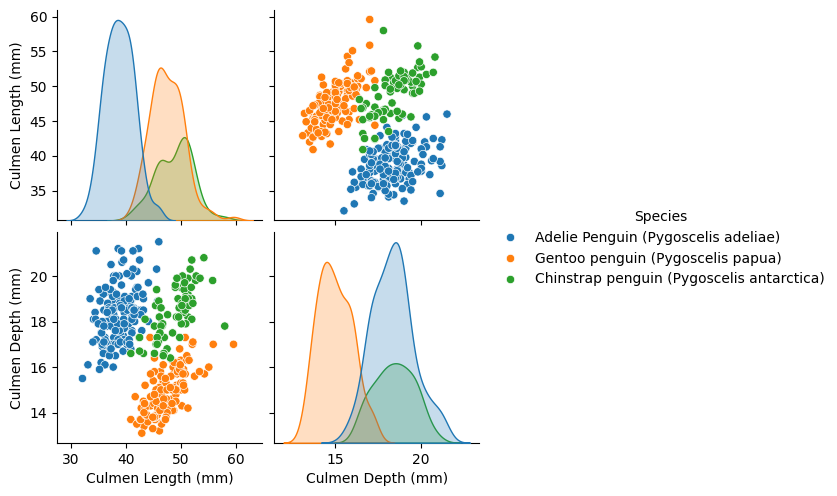

In [ ]:
import seaborn

pairplot_figure = seaborn.pairplot(penguins_classification, hue=target_column)
# pairplot_figure.fig.set_size_inches(9, 6.5)

Looking at these distributions, how hard do you think it would be to classify the penguins only using **culmen depth** and **culmen length**?


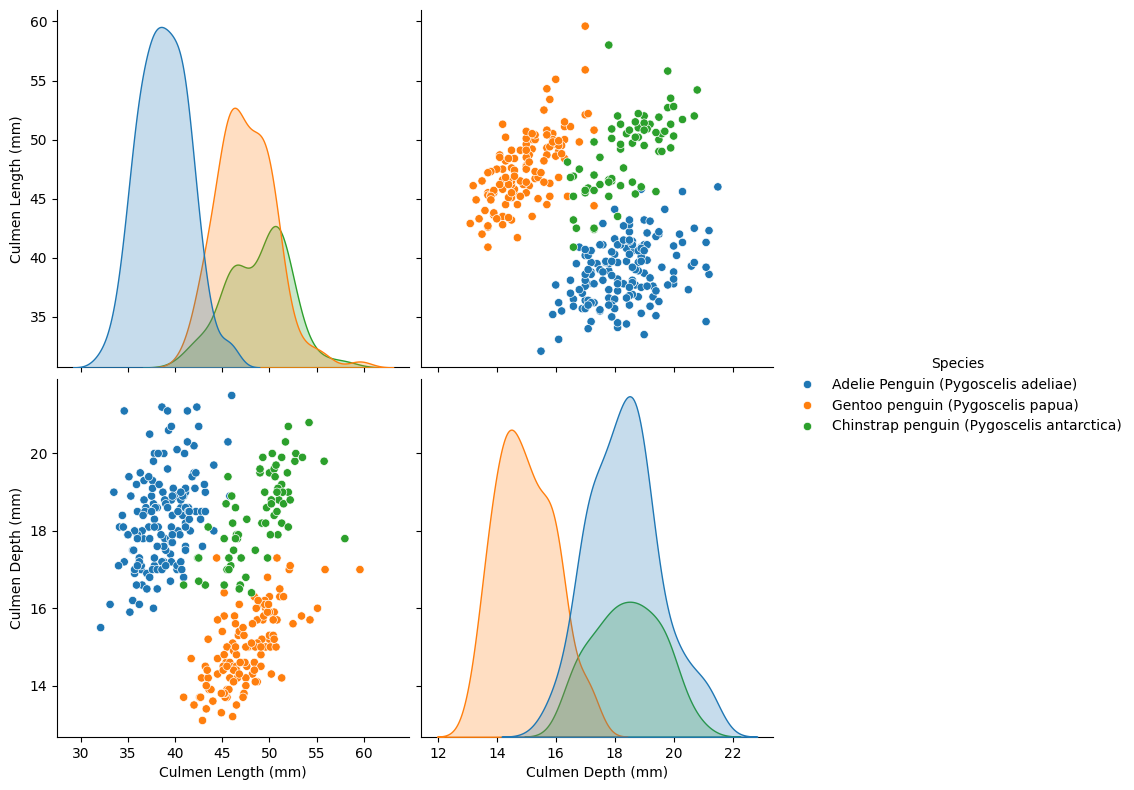

In [ ]:
pairplot_figure = seaborn.pairplot(penguins_classification, hue=target_column, height=4)


# Regression example

In a regression setting, the target is a continuous variable instead of categories. Here, we use two features of the dataset to make such a problem: the flipper length is used as data and the body mass as the target. In short, we want to predict the body mass using the flipper length.

We load the dataset and visualize the relationship between the flipper length and the body mass of penguins.

In [ ]:
# penguins = pd.read_csv("../datasets/penguins_regression.csv")

feature_name = "Flipper Length (mm)"
target_column = "Body Mass (g)"
features = [feature_name, target_column]


penguins_regression = penguins[features]

In [ ]:
penguins_regression

,Flipper Length (mm),Body Mass (g)
0,181.0,3750.0
1,186.0,3800.0
2,195.0,3250.0
3,NaN,NaN
4,193.0,3450.0
...,...,...
339,207.0,4000.0
340,202.0,3400.0
341,193.0,3775.0
342,210.0,4100.0


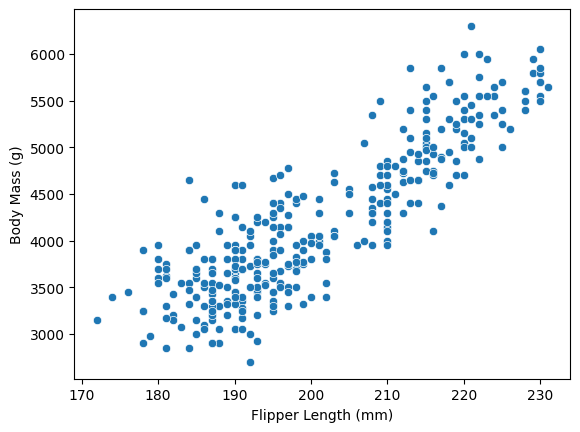

In [ ]:
# run the cell that imports sns or uncomment below
# import seaborn as sns

_ = sns.scatterplot(data=penguins_regression, x=feature_name, y=target_column)

Here, we deal with a regression problem because our target is a continuous variable ranging from 2.7 kg to 6.3 kg. From the scatter plot above, we observe that we have a linear relationship between the flipper length and the body mass. The longer the flipper of a penguin, the heavier the penguin.